# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
%run w06_validation_audit.ipynb


Finding 1 (Finding #4 - "The Freshness Multiplier"):
365+ day content that was refreshed within the last 30 days shows a 3.2x health-score
boost (10.7 -> 34.5) and 57x more impressions (71 -> 4,039) than 365+ day content that
was not refreshed.

Methodology question:
Which pages get "refreshed" is an editorial decision, not a random assignment. Editors
plausibly pick older pages that already show some early recovery signal, keyword demand,
or business priority to refresh -- not a random sample of stale pages. So the label
"refreshed vs not" is entangled with whatever made a page worth refreshing in the first
place.

Validation question:
This is a before/after comparison on an editor-selected group, not a randomized
experiment, so it cannot rule out that the pages chosen for refresh were already on a
different trajectory before the refresh happened. The paper itself flags a related
version of this problem for the neighboring 361+ freshness bucket (283:1 ratio on only
1 declining page) 

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Define and train group_model as a RandomForestClassifier
# Assuming default parameters are sufficient for this fix, or can be tuned later.
group_model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
group_model.fit(X_tr, y_tr)

playbook = model_data_90d.copy()

playbook["declining_probability"] = group_model.predict_proba(
    playbook[feature_cols_90d]
)[:, 1]

playbook = playbook.sort_values(
    "declining_probability",
    ascending=False
).reset_index(drop=True)

print("Pages scored:", len(playbook))
playbook.head()

Pages scored: 87735


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,pos_volatility_last30,is_declining,declining_probability
0,client_e547b89c05043229,content_99f8821e235222d9,46.0,83.0,199.0,0.0,28.283234,1.0,0.140244,0.823171,12.0,12.0,1.000000,29.842762,1,1.0
1,client_e547b89c05043229,content_33f2374ac2ade508,31.0,140.0,213.0,1.0,22.009524,2.0,0.093750,0.781250,36.0,48.0,0.750000,32.108764,1,1.0
2,client_73cda7b4e4f265ea,content_208fd36ae6b330ec,872.0,2018.0,2421.0,2.0,13.050532,17.0,0.058181,0.877424,50.0,342.0,0.146199,10.183931,1,1.0
3,client_23a62021009f63c4,content_e6e1b59621235d28,529.0,1029.0,1052.0,1.0,25.329712,3.0,0.047510,0.892720,84.0,156.0,0.538462,13.711028,1,1.0
4,client_23a62021009f63c4,content_42cf291d2d9af361,1906.0,7081.0,12045.0,9.0,39.810969,54.0,0.024867,0.906761,159.0,1438.0,0.110570,5.287750,1,1.0


In [5]:
import pandas as pd
import numpy as np

playbook = model_data_90d.copy()

playbook["declining_probability"] = group_model.predict_proba(
    playbook[feature_cols_90d]
)[:, 1]

playbook = playbook.sort_values(
    "declining_probability",
    ascending=False
).reset_index(drop=True)

print("Pages scored:", len(playbook))
playbook.head()

Pages scored: 87735


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,pos_volatility_last30,is_declining,declining_probability
0,client_e547b89c05043229,content_99f8821e235222d9,46.0,83.0,199.0,0.0,28.283234,1.0,0.140244,0.823171,12.0,12.0,1.000000,29.842762,1,1.0
1,client_e547b89c05043229,content_33f2374ac2ade508,31.0,140.0,213.0,1.0,22.009524,2.0,0.093750,0.781250,36.0,48.0,0.750000,32.108764,1,1.0
2,client_73cda7b4e4f265ea,content_208fd36ae6b330ec,872.0,2018.0,2421.0,2.0,13.050532,17.0,0.058181,0.877424,50.0,342.0,0.146199,10.183931,1,1.0
3,client_23a62021009f63c4,content_e6e1b59621235d28,529.0,1029.0,1052.0,1.0,25.329712,3.0,0.047510,0.892720,84.0,156.0,0.538462,13.711028,1,1.0
4,client_23a62021009f63c4,content_42cf291d2d9af361,1906.0,7081.0,12045.0,9.0,39.810969,54.0,0.024867,0.906761,159.0,1438.0,0.110570,5.287750,1,1.0


In [6]:
def get_reason(row):
    reasons = []

    if row["imp_last30"] < 0.8 * row["imp_mid30"]:
        reasons.append("DECLINING_IMPRESSIONS")

    if row["pos_volatility_last30"] > playbook["pos_volatility_last30"].median():
        reasons.append("POSITION_VOLATILITY")

    if row["top_query_share"] > playbook["top_query_share"].median():
        reasons.append("QUERY_CONCENTRATION")

    if row["visible_queries"] < playbook["visible_queries"].median():
        reasons.append("LOW_QUERY_VISIBILITY")

    return reasons[0] if reasons else "MODEL_PRIORITY"

playbook["reason_code"] = playbook.apply(get_reason, axis=1)

playbook[[
    "content_hash_id",
    "declining_probability",
    "reason_code"
]].head(10)

,content_hash_id,declining_probability,reason_code
0,content_99f8821e235222d9,1.0,DECLINING_IMPRESSIONS
1,content_33f2374ac2ade508,1.0,DECLINING_IMPRESSIONS
2,content_208fd36ae6b330ec,1.0,DECLINING_IMPRESSIONS
3,content_e6e1b59621235d28,1.0,DECLINING_IMPRESSIONS
4,content_42cf291d2d9af361,1.0,DECLINING_IMPRESSIONS
5,content_389443ea951d09a7,1.0,DECLINING_IMPRESSIONS
6,content_eb976ba40b7369cc,1.0,DECLINING_IMPRESSIONS
7,content_e6f0ab22e29a7744,1.0,DECLINING_IMPRESSIONS
8,content_7bddc2288f6b0f4b,1.0,DECLINING_IMPRESSIONS
9,content_5142a5e6819fb5b4,1.0,DECLINING_IMPRESSIONS


In [7]:
def get_action(reason):
    actions = {
        "DECLINING_IMPRESSIONS": "Review and refresh content",
        "POSITION_VOLATILITY": "Review rankings and SERP alignment",
        "QUERY_CONCENTRATION": "Review query coverage and intent",
        "LOW_QUERY_VISIBILITY": "Review targeting and discoverability",
        "MODEL_PRIORITY": "Manual content review"
    }

    return actions.get(reason, "Manual content review")

playbook["action"] = playbook["reason_code"].map(get_action)

playbook[[
    "content_hash_id",
    "declining_probability",
    "reason_code",
    "action"
]].head(10)

,content_hash_id,declining_probability,reason_code,action
0,content_99f8821e235222d9,1.0,DECLINING_IMPRESSIONS,Review and refresh content
1,content_33f2374ac2ade508,1.0,DECLINING_IMPRESSIONS,Review and refresh content
2,content_208fd36ae6b330ec,1.0,DECLINING_IMPRESSIONS,Review and refresh content
3,content_e6e1b59621235d28,1.0,DECLINING_IMPRESSIONS,Review and refresh content
4,content_42cf291d2d9af361,1.0,DECLINING_IMPRESSIONS,Review and refresh content
5,content_389443ea951d09a7,1.0,DECLINING_IMPRESSIONS,Review and refresh content
6,content_eb976ba40b7369cc,1.0,DECLINING_IMPRESSIONS,Review and refresh content
7,content_e6f0ab22e29a7744,1.0,DECLINING_IMPRESSIONS,Review and refresh content
8,content_7bddc2288f6b0f4b,1.0,DECLINING_IMPRESSIONS,Review and refresh content
9,content_5142a5e6819fb5b4,1.0,DECLINING_IMPRESSIONS,Review and refresh content


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [8]:
'''Intended use:

The output is a ranked review queue for content teams. Pages with higher model scores should be reviewed earlier by a human. The reason code provides a simple explanation for why a page received its action recommendation.

The output is decision support, not an automatic content-management system.

Limits:

The model is trained on the available search and content signals and the defined declining-performance label. It does not establish why a page declined, does not predict Google's algorithm, and does not guarantee that refreshing a page will improve performance.

The ranking should therefore be treated as directional prioritization rather than an automatic decision.'''

"Intended use:\n\nThe output is a ranked review queue for content teams. Pages with higher model scores should be reviewed earlier by a human. The reason code provides a simple explanation for why a page received its action recommendation.\n\nThe output is decision support, not an automatic content-management system.\n\nLimits:\n\nThe model is trained on the available search and content signals and the defined declining-performance label. It does not establish why a page declined, does not predict Google's algorithm, and does not guarantee that refreshing a page will improve performance.\n\nThe ranking should therefore be treated as directional prioritization rather than an automatic decision."

In [9]:
'''### Archetype → action mapping

| Observed pattern | Suggested action |
|---|---|
| Declining impressions | Review and refresh content |
| High position volatility | Review SERP alignment and ranking stability |
| High query concentration | Expand relevant query coverage |
| Low query visibility | Review targeting and discoverability |
| High model priority without a clear signal | Manual review before action |

These mappings are decision-support suggestions. They do not establish that the listed action will cause recovery.'''

'### Archetype → action mapping\n\n| Observed pattern | Suggested action |\n|---|---|\n| Declining impressions | Review and refresh content |\n| High position volatility | Review SERP alignment and ranking stability |\n| High query concentration | Expand relevant query coverage |\n| Low query visibility | Review targeting and discoverability |\n| High model priority without a clear signal | Manual review before action |\n\nThese mappings are decision-support suggestions. They do not establish that the listed action will cause recovery.'

In [10]:
'''### Decay / refresh insight

The analysis suggests that content performance should be monitored as content ages and search performance changes. The research paper also reports that mature pages that were recently refreshed performed strongly in its age × freshness comparison.

This should be treated as an observed association rather than causal proof that refreshing content produces the improvement.

Therefore, content age and recent performance changes can be used to prioritize review, while the actual refresh decision remains with a human reviewer.'''

'### Decay / refresh insight\n\nThe analysis suggests that content performance should be monitored as content ages and search performance changes. The research paper also reports that mature pages that were recently refreshed performed strongly in its age × freshness comparison.\n\nThis should be treated as an observed association rather than causal proof that refreshing content produces the improvement.\n\nTherefore, content age and recent performance changes can be used to prioritize review, while the actual refresh decision remains with a human reviewer.'

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [11]:
'''### Human review rules

A reviewer should check:

1. Whether the page is actually relevant to the business.
2. Whether the observed decline is large enough to justify intervention.
3. Whether the page's search intent has changed.
4. Whether the content is still accurate and useful.
5. Whether there are technical or SERP-related explanations for the change.
6. Whether refreshing the content is appropriate before making an edit.

### Do NOT automate

The system should not automatically:

- publish content changes;
- delete pages;
- rewrite pages;
- change search intent;
- change titles or metadata without review;
- declare a page successful or unsuccessful from the model score alone;
- claim that a model score proves causation.'''

"### Human review rules\n\nA reviewer should check:\n\n1. Whether the page is actually relevant to the business.\n2. Whether the observed decline is large enough to justify intervention.\n3. Whether the page's search intent has changed.\n4. Whether the content is still accurate and useful.\n5. Whether there are technical or SERP-related explanations for the change.\n6. Whether refreshing the content is appropriate before making an edit.\n\n### Do NOT automate\n\nThe system should not automatically:\n\n- publish content changes;\n- delete pages;\n- rewrite pages;\n- change search intent;\n- change titles or metadata without review;\n- declare a page successful or unsuccessful from the model score alone;\n- claim that a model score proves causation."

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [12]:
'''### Monitoring

The model should be monitored for:

- changes in the percentage of pages classified as declining;
- changes in precision on newly reviewed outcomes;
- changes in the distribution of important features;
- changes in the number of pages receiving each reason code;
- changes in search behavior or data availability.

### Retrain triggers

A retraining review should be considered when:

- model precision drops materially;
- the underlying data distribution changes;
- the definition of declining performance changes;
- important features become unavailable;
- the search environment changes substantially;
- enough new labeled outcomes become available to justify another evaluation.

Retraining should not happen simply because a new model is available. The model should first show that the existing system no longer provides useful decision support.'''

'### Monitoring\n\nThe model should be monitored for:\n\n- changes in the percentage of pages classified as declining;\n- changes in precision on newly reviewed outcomes;\n- changes in the distribution of important features;\n- changes in the number of pages receiving each reason code;\n- changes in search behavior or data availability.\n\n### Retrain triggers\n\nA retraining review should be considered when:\n\n- model precision drops materially;\n- the underlying data distribution changes;\n- the definition of declining performance changes;\n- important features become unavailable;\n- the search environment changes substantially;\n- enough new labeled outcomes become available to justify another evaluation.\n\nRetraining should not happen simply because a new model is available. The model should first show that the existing system no longer provides useful decision support.'

In [13]:
'''### Cost and value

A false positive sends a healthy or non-priority page to human review. Its main cost is reviewer time.

A false negative means a genuinely declining page may be missed. Its potential cost is losing an opportunity to investigate declining search performance.

Because both errors have costs, the queue should prioritize pages where the expected value of review is high rather than treating every model prediction as an automatic action.

The model therefore helps allocate limited content-review time.'''

'### Cost and value\n\nA false positive sends a healthy or non-priority page to human review. Its main cost is reviewer time.\n\nA false negative means a genuinely declining page may be missed. Its potential cost is losing an opportunity to investigate declining search performance.\n\nBecause both errors have costs, the queue should prioritize pages where the expected value of review is high rather than treating every model prediction as an automatic action.\n\nThe model therefore helps allocate limited content-review time.'

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [14]:
import os

os.makedirs("work/outputs", exist_ok=True)

queue = playbook[[
    "content_hash_id",
    "client_hash_id",
    "declining_probability",
    "reason_code",
    "action"
]].copy()

queue.to_csv(
    "work/outputs/action_playbook_queue.csv",
    index=False
)

print("Exported:")
print("work/outputs/action_playbook_queue.csv")
print("Rows:", len(queue))

queue.head(10)

Exported:
work/outputs/action_playbook_queue.csv
Rows: 87735


,content_hash_id,client_hash_id,declining_probability,reason_code,action
0,content_99f8821e235222d9,client_e547b89c05043229,1.0,DECLINING_IMPRESSIONS,Review and refresh content
1,content_33f2374ac2ade508,client_e547b89c05043229,1.0,DECLINING_IMPRESSIONS,Review and refresh content
2,content_208fd36ae6b330ec,client_73cda7b4e4f265ea,1.0,DECLINING_IMPRESSIONS,Review and refresh content
3,content_e6e1b59621235d28,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
4,content_42cf291d2d9af361,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
5,content_389443ea951d09a7,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
6,content_eb976ba40b7369cc,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
7,content_e6f0ab22e29a7744,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
8,content_7bddc2288f6b0f4b,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
9,content_5142a5e6819fb5b4,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content


In [15]:
top10 = queue.head(10)

top10.to_csv(
    "work/outputs/action_playbook_top10.csv",
    index=False
)

top10

,content_hash_id,client_hash_id,declining_probability,reason_code,action
0,content_99f8821e235222d9,client_e547b89c05043229,1.0,DECLINING_IMPRESSIONS,Review and refresh content
1,content_33f2374ac2ade508,client_e547b89c05043229,1.0,DECLINING_IMPRESSIONS,Review and refresh content
2,content_208fd36ae6b330ec,client_73cda7b4e4f265ea,1.0,DECLINING_IMPRESSIONS,Review and refresh content
3,content_e6e1b59621235d28,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
4,content_42cf291d2d9af361,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
5,content_389443ea951d09a7,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
6,content_eb976ba40b7369cc,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
7,content_e6f0ab22e29a7744,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
8,content_7bddc2288f6b0f4b,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content
9,content_5142a5e6819fb5b4,client_23a62021009f63c4,1.0,DECLINING_IMPRESSIONS,Review and refresh content


In [16]:
import os

os.makedirs("work/figures", exist_ok=True)

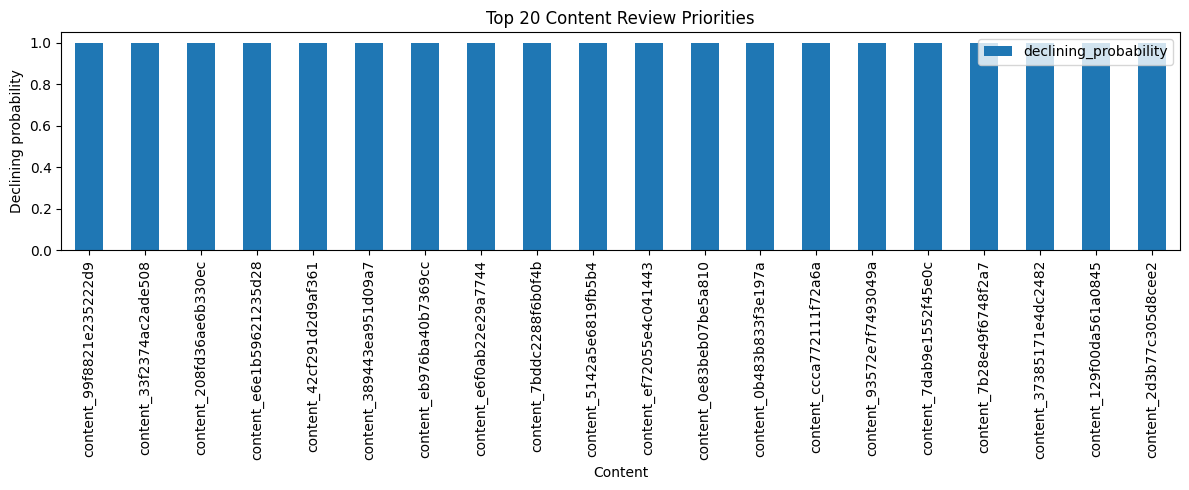

In [17]:
import matplotlib.pyplot as plt

queue.head(20).plot(
    x="content_hash_id",
    y="declining_probability",
    kind="bar",
    figsize=(12, 5),
    title="Top 20 Content Review Priorities"
)

plt.ylabel("Declining probability")
plt.xlabel("Content")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "work/figures/top20_review_priorities.png",
    dpi=150
)

plt.show()

In [18]:
checks = {
    "Ranked queue created": len(queue) > 0,
    "Reason codes included": "reason_code" in queue.columns,
    "Actions included": "action" in queue.columns,
    "Queue exported": os.path.exists(
        "work/outputs/action_playbook_queue.csv"
    ),
    "Top 10 exported": os.path.exists(
        "work/outputs/action_playbook_top10.csv"
    ),
    "Figure exported": os.path.exists(
        "work/figures/top20_review_priorities.png"
    ),
    "Human review required": True,
    "No automatic publishing": True,
    "Monitoring triggers defined": True
}

for item, status in checks.items():
    print(("✓" if status else "✗"), item)

✓ Ranked queue created
✓ Reason codes included
✓ Actions included
✓ Queue exported
✓ Top 10 exported
✓ Figure exported
✓ Human review required
✓ No automatic publishing
✓ Monitoring triggers defined


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.